# 01 - Initial Discovery
GitHub Repository Activity Dataset - Phase 1 EDA
ENSA Tetouan | ML 2025-2026

**Authors:** Ismail LYAMANI, Abdellatif OUMHELLA, Mohammed Aymane SABER

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_csv('../data/dataset.csv')
print(f'Shape: {df.shape}')

Shape: (12000, 22)


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   full_name                 12000 non-null  object 
 1   collected_at              12000 non-null  object 
 2   stars                     12000 non-null  int64  
 3   forks                     12000 non-null  int64  
 4   open_issues               12000 non-null  int64  
 5   watchers                  12000 non-null  int64  
 6   size_kb                   12000 non-null  int64  
 7   repo_age_days             12000 non-null  int64  
 8   days_since_last_push      12000 non-null  int64  
 9   contributor_count         12000 non-null  int64  
 10  avg_issue_response_hours  12000 non-null  float64
 11  engagement_rate           12000 non-null  float64
 12  stars_forks_ratio         12000 non-null  float64
 13  language                  12000 non-null  object 
 14  licens

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
stars,12000.0,1199.635000,4.292598e+03,0.0,9.0000,31.00000,273.000000,4.914600e+04
forks,12000.0,195.023000,7.844953e+02,0.0,2.0000,9.00000,63.000000,3.381500e+04
open_issues,12000.0,53.522833,3.776066e+02,0.0,0.0000,3.00000,23.000000,3.051100e+04
watchers,12000.0,1199.635000,4.292598e+03,0.0,9.0000,31.00000,273.000000,4.914600e+04
size_kb,12000.0,252780.977167,2.056113e+06,0.0,1294.7500,9178.00000,56248.000000,7.810495e+07
repo_age_days,12000.0,1638.710250,1.510318e+03,30.0,304.0000,1161.00000,2692.000000,6.564000e+03
days_since_last_push,12000.0,285.300250,9.020831e+02,0.0,0.0000,0.00000,1.000000,6.563000e+03
contributor_count,12000.0,21.000333,3.108209e+01,-1.0,2.0000,5.00000,25.000000,1.000000e+02
avg_issue_response_hours,12000.0,1880.169811,6.073580e+03,-1.0,-1.0000,2.44500,724.052500,1.148668e+05
engagement_rate,12000.0,2.388451,2.149891e+01,0.0,0.0113,0.06395,0.392525,1.499375e+03


In [21]:
df.head()

,full_name,collected_at,stars,forks,open_issues,watchers,size_kb,repo_age_days,days_since_last_push,contributor_count,...,stars_forks_ratio,language,license,has_description,has_homepage,has_wiki,has_projects,is_fork,archived,is_inactive
0,coldfix/udiskie,2026-05-05T22:42:26.758887+00:00,1032,60,30,1032,1832,4620,1,40,...,17.20,Python,MIT License,1,0,1,1,0,0,0
1,PlasmaControl/DESC,2026-05-05T16:37:35.517009+00:00,157,47,279,157,2794899,2127,0,41,...,3.34,Python,MIT License,1,1,0,1,0,0,0
2,mtheli/philips_sonicare_ble,2026-05-05T21:41:06.832991+00:00,14,2,1,14,846,48,0,2,...,7.00,Python,MIT License,1,0,0,1,0,0,0
3,wkentaro/gdown,2026-05-05T23:13:22.074506+00:00,5234,411,0,5234,1303,3853,23,25,...,12.73,Python,MIT License,1,0,0,0,0,0,0
4,ynput/ayon-shotgrid,2026-05-05T15:46:13.611723+00:00,12,16,40,12,3694,1197,0,20,...,0.75,Python,Apache License 2.0,1,0,1,1,0,0,0


## Class distribution (imbalance check)

In [22]:
counts = df['is_inactive'].value_counts().sort_index()
labels = ['Active (0)', 'Inactive (1)']
pct = counts / len(df) * 100

print('=== Class distribution ===')
for cls, cnt, p in zip(labels, counts, pct):
    print(f'  {cls}: {cnt:>6}  ({p:.1f}%)')
minority_pct = pct.iloc[1]
status = 'VALID' if 5 <= minority_pct <= 25 else 'WARNING'
print(f'\nMinority class ratio: {minority_pct:.1f}%  [{status}]')

=== Class distribution ===
  Active (0):  10445  (87.0%)
  Inactive (1):   1555  (13.0%)

Minority class ratio: 13.0%  [VALID]


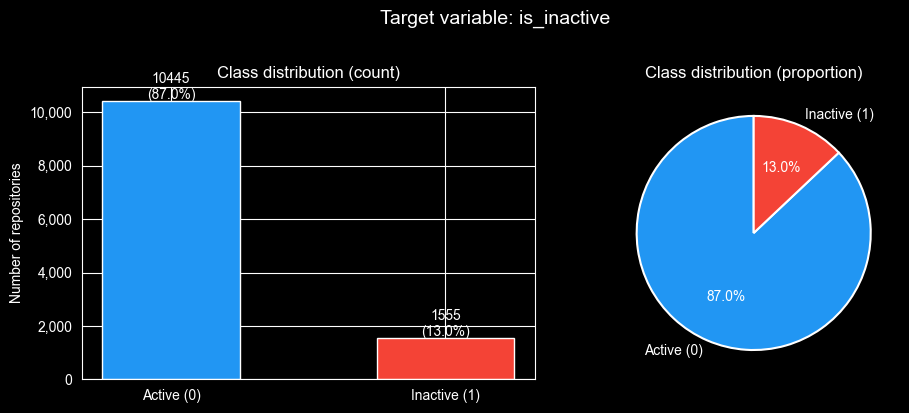

Saved to data/class_distribution.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#2196F3', '#F44336']
axes[0].bar(labels, counts.values, color=colors, width=0.5)
for i, (cnt, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, cnt + 50, f'{cnt}\n({p:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Class distribution (count)', fontsize=12)
axes[0].set_ylabel('Number of repositories')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'})
axes[1].set_title('Class distribution (proportion)', fontsize=12)
plt.suptitle('Target variable: is_inactive', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/class_distribution.png')

## Missing values

In [24]:
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct.round(2)})
missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
license,3355,27.96


## Feature distributions (all numeric columns)

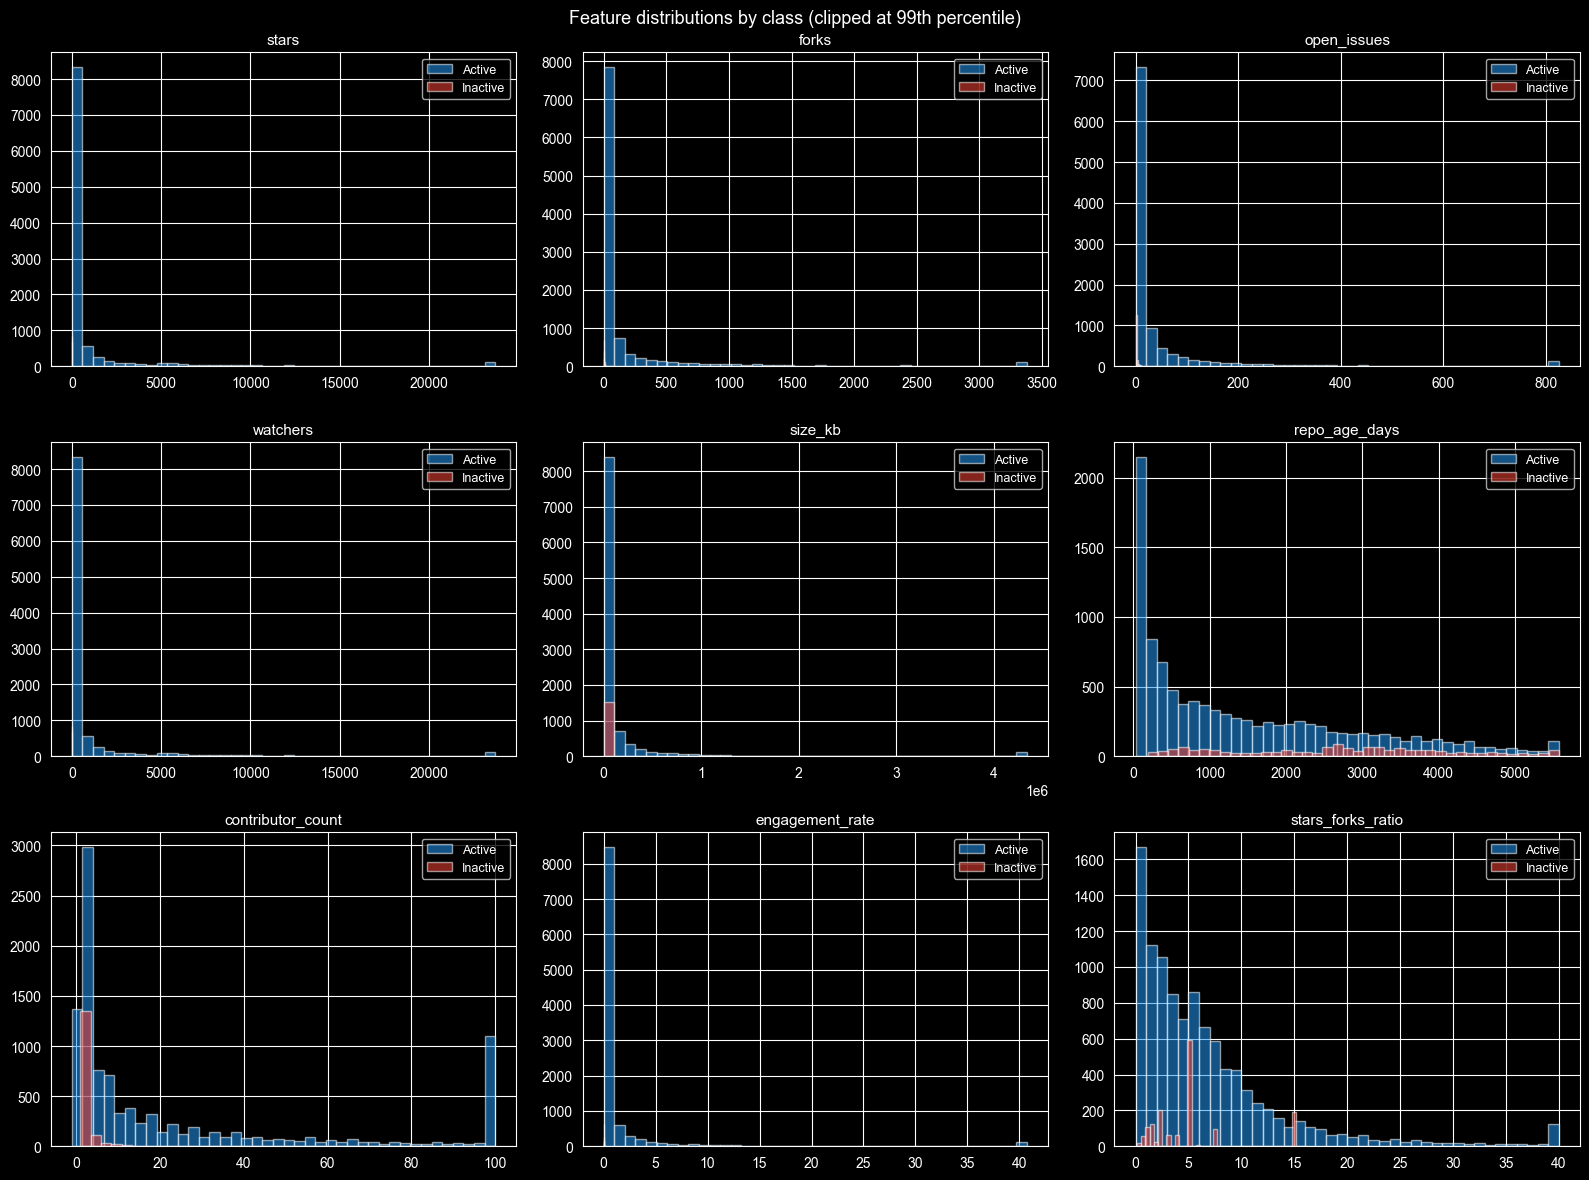

In [25]:
numeric_cols = [
    'stars', 'forks', 'open_issues', 'watchers', 'size_kb',
    'repo_age_days', 'contributor_count', 'engagement_rate',
    'stars_forks_ratio', 'avg_issue_response_hours'
]
plot_cols = [c for c in numeric_cols if c != 'avg_issue_response_hours']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    for cls, clr, lbl in [(0, '#2196F3', 'Active'), (1, '#F44336', 'Inactive')]:
        subset = df[df['is_inactive'] == cls][col].clip(upper=df[col].quantile(0.99))
        axes[i].hist(subset, bins=40, alpha=0.55, color=clr, label=lbl)
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=9)
plt.suptitle('Feature distributions by class (clipped at 99th percentile)', fontsize=13)
plt.tight_layout()
plt.show()

Repos with no closed issues (sentinel -1.0): 47.7%


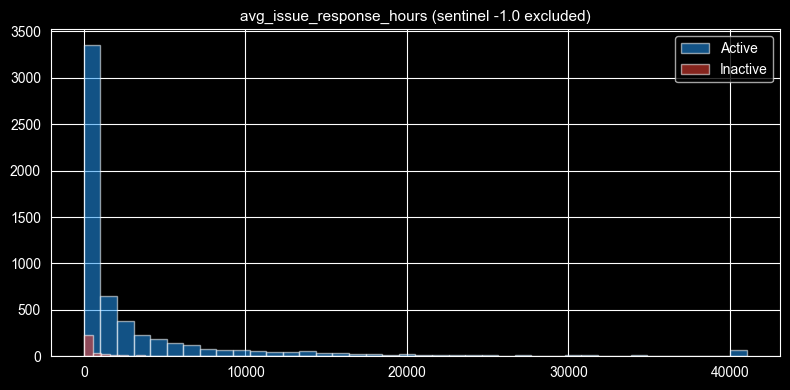

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
for cls, clr, lbl in [(0, '#2196F3', 'Active'), (1, '#F44336', 'Inactive')]:
    subset = df[(df['is_inactive'] == cls) & (df['avg_issue_response_hours'] >= 0)]['avg_issue_response_hours']
    subset = subset.clip(upper=subset.quantile(0.99))
    ax.hist(subset, bins=40, alpha=0.55, color=clr, label=lbl)
ax.set_title('avg_issue_response_hours (sentinel -1.0 excluded)', fontsize=11)
ax.legend()
pct_sentinel = (df['avg_issue_response_hours'] == -1.0).mean() * 100
print(f'Repos with no closed issues (sentinel -1.0): {pct_sentinel:.1f}%')
plt.tight_layout()
plt.show()

## Categorical distributions

In [27]:
print('--- Top 10 languages ---')
print(df['language'].value_counts().head(10))
print('\n--- Top 10 licenses ---')
print(df['license'].value_counts().head(10))

--- Top 10 languages ---
language
Python        8380
JavaScript    3616
Unknown          4
Name: count, dtype: int64

--- Top 10 licenses ---
license
MIT License                                3590
Apache License 2.0                         1629
Other                                      1125
GNU General Public License v3.0             838
GNU Affero General Public License v3.0      441
BSD 3-Clause "New" or "Revised" License     346
GNU General Public License v2.0             145
Mozilla Public License 2.0                   97
BSD 2-Clause "Simplified" License            79
Creative Commons Zero v1.0 Universal         65
Name: count, dtype: int64


## Correlation heatmap

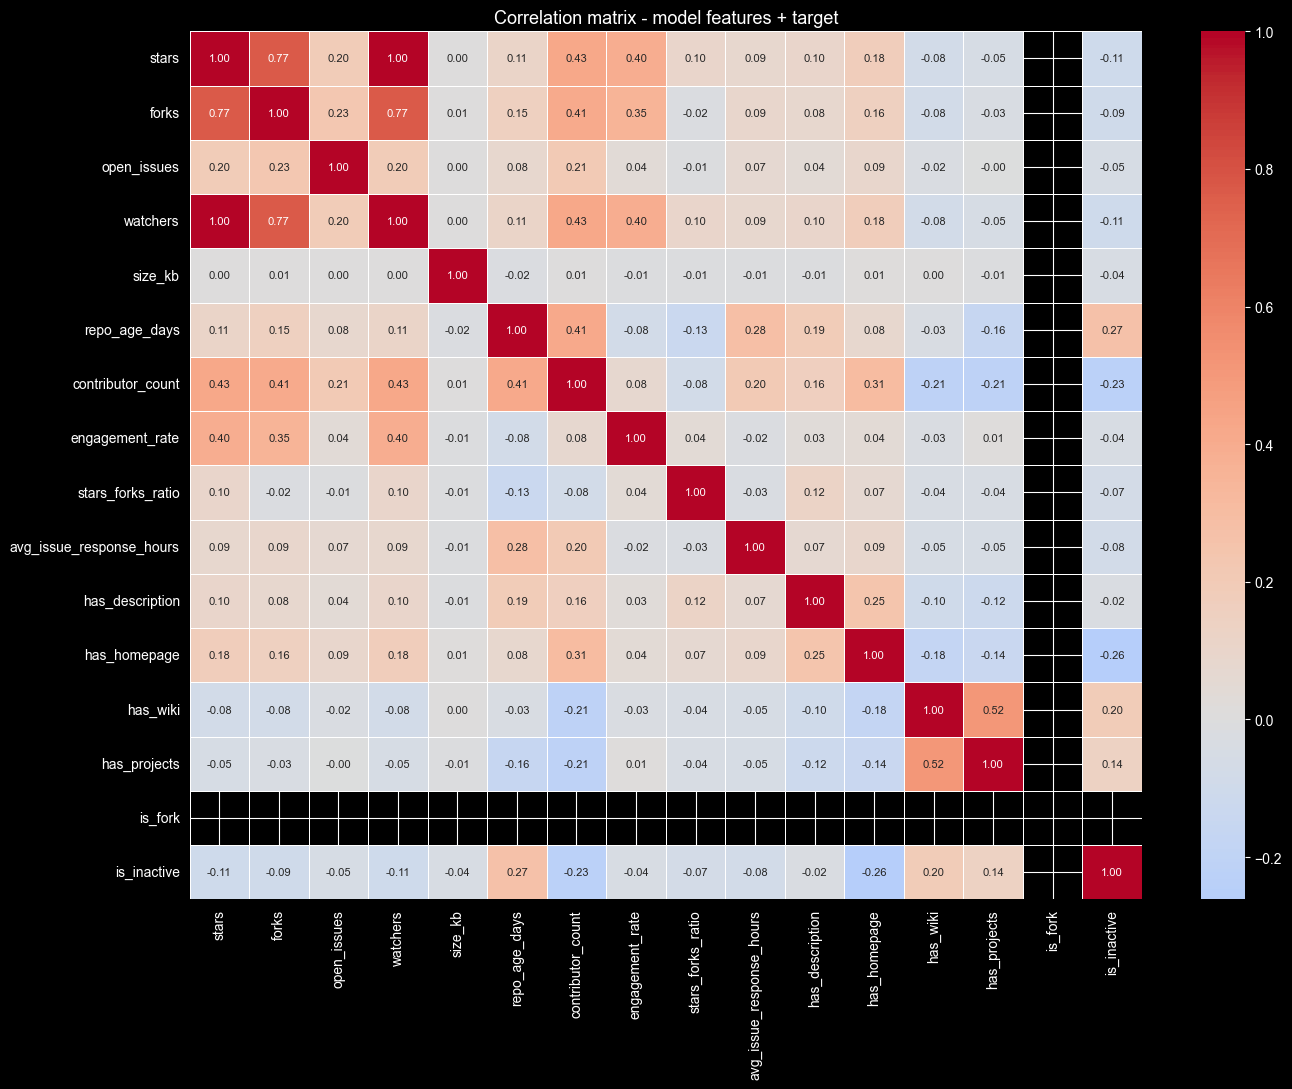

Saved to data/correlation_matrix.png

Top correlations with is_inactive:
repo_age_days               0.273304
has_homepage               -0.261446
contributor_count          -0.229280
has_wiki                    0.195685
has_projects                0.139836
stars                      -0.106978
watchers                   -0.106978
forks                      -0.094425
avg_issue_response_hours   -0.083517
stars_forks_ratio          -0.072692
open_issues                -0.053368
size_kb                    -0.042731
engagement_rate            -0.042723
has_description            -0.021599
is_fork                          NaN


In [28]:
model_cols = [
    'stars', 'forks', 'open_issues', 'watchers', 'size_kb',
    'repo_age_days', 'contributor_count', 'engagement_rate',
    'stars_forks_ratio', 'avg_issue_response_hours',
    'has_description', 'has_homepage', 'has_wiki', 'has_projects', 'is_fork',
    'is_inactive'
]
corr = df[model_cols].corr()
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation matrix - model features + target', fontsize=13)
plt.tight_layout()
plt.savefig('../data/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/correlation_matrix.png')
print('\nTop correlations with is_inactive:')
print(corr['is_inactive'].drop('is_inactive').sort_values(key=abs, ascending=False).to_string())

## Leakage warning check

In [29]:
print('Columns to DROP before modeling (data leakage):')
print('  - days_since_last_push  (directly encodes the label)')
print('  - archived              (post-hoc label, not predictive feature)')
print('  - full_name             (identifier)')
print('  - collected_at          (identifier)')
print()
print('All other columns are safe to use as features.')

Columns to DROP before modeling (data leakage):
  - days_since_last_push  (directly encodes the label)
  - archived              (post-hoc label, not predictive feature)
  - full_name             (identifier)
  - collected_at          (identifier)

All other columns are safe to use as features.
